In [21]:
# Author: Ethan Stroberg
# National Severe Storms Laboratory
# This code last updated on March 12, 2025
#
# Version 1.6 - adding plots that visualize classificaions vs variables
# Version 1.5 - added T, RH, and P data from .csv and .txt files, includes addition of functions
# Version 1.4 - updated to give a user-based description of classifications
# Version 1.3 - updated to only use majority rules cases, normalized dataset
# Verison 1.2 - added machine learning models
# Version 1.1 - updated to only take in values classified as 2 or less
# Version 1.0 - original code written by Mike to read in data and plot histograms
#
# finally decided to keep track of the versions lol, I think this is somewhat how it's gone (- me 2/20)


In [22]:
#imports
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score
import sklearn
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
warnings.filterwarnings('ignore')

In [23]:
# create any relevant functions
# frame_extractor: extracts the image frame from the list of filenames in the IOP10 file
def frame_extractor(filename):
    parts = filename.split('_')
    frame_number = parts[-1].split('.')[0]
    return frame_number

# time_extractor: extracts the time of day from the list of filenames in the IOP10 file and converts to HH:MM:SS format
def time_extractor(filename):
    parts = filename.split('_')
    time_list = parts[0].split('-')[-3:]
    time_colon_format = ":".join(map(str, time_list))
    return time_colon_format

In [24]:
#read in the file
hdfFile = h5py.File('pasive_manualclassification_condensed2.h5', 'r')

#create dictionary to store the data
particleTable = {}
print('Reading in hdf5 file')

#list all keys in the file
hdfKeys = list(hdfFile.keys())
N = len(hdfKeys)
# create a list of hdfKeys that will be added to the dataframe later
valid_keys = []

for i, key in enumerate(hdfKeys):
    dset = hdfFile[key]

    #check the 'classifications' attribute
    if 'classifications' in dset.attrs:
        classifications = dset.attrs['classifications']

        valueCount = [0,0,0]
        for user, value in classifications:
            if value <= 2:
                valueCount[value] += 1

        majority = np.argmax( valueCount )

        #check to see that there isn't a tie
        maxCount = 0
        for count in valueCount:
            if count == max( valueCount ): maxCount += 1
        if maxCount != 1:
            #there is a tie, that's not good
            continue
        
        # add each valid key to the list for the dataframe later
        valid_keys.append(key)

        for attr in dset.attrs:
            if attr not in particleTable:
                particleTable[attr] = []
            if attr == 'classifications':
                #we already filtered these, we handle this special
                particleTable[attr].append( majority )
            else:
                particleTable[attr].append(dset.attrs[attr])   
    else:
        #there isn't a classification for this particle, wack
        #probably we don't need this else because we're at the end of the loop
        continue     
    
print(f"Filtered data has been loaded into particleTable with {len(particleTable)} attributes.")

Reading in hdf5 file
Filtered data has been loaded into particleTable with 31 attributes.


In [25]:
# print( particleTable.keys() )
# print( min(particleTable['image']), max(particleTable['image']),)

In [26]:
#for key in particleTable:
#    print( key.ljust(15), len( particleTable[key]) )

print( 'The following classifications were issued')
classificationCounts = {}
for value in particleTable['classifications']:
    if not value in classificationCounts:
        classificationCounts[value] = 0
    classificationCounts[value] += 1

classificationHeader = particleTable['classification_header'][0]
for key in classificationCounts:
    print( '%s %5i'%(classificationHeader[key], classificationCounts[key]) )

# for k in particleTable:
#     print ( k, len(particleTable[k]) )
print( len(hdfKeys))

The following classifications were issued
s 10389
i  1916
b  2102
15008


In [27]:
# Count how many times each user classified each classification

# make lists to store the number of times each user classified each type
count3195 = [0, 0, 0]
count3194 = [0, 0, 0]
count3225 = [0, 0, 0]
count3128 = [0, 0, 0]

for i, key in enumerate(hdfKeys):
    dset = hdfFile[key]
    if 'classifications' in dset.attrs:
        classifications = dset.attrs['classifications']
        for user, value in classifications:
            # if the value is allowed and fits a particular user, append that user's count list
            if value <= 2:
                if user == 3195:
                    count3195[value] += 1
                elif user == 3194:
                    count3194[value] += 1
                elif user == 3225:
                    count3225[value] += 1
                elif user == 3128:
                    count3128[value] += 1
                    
# calculate percentages for each user
#3195
snow3195 = count3195[0] / (count3195[0] + count3195[1] + count3195[2]) * 100
broken3195 = count3195[1] / (count3195[0] + count3195[1] + count3195[2]) * 100
ice3195 =count3195[2] / (count3195[0] + count3195[1] + count3195[2]) * 100
#3194
snow3194 = count3194[0] / (count3194[0] + count3194[1] + count3194[2]) * 100
broken3194 = count3194[1] / (count3194[0] + count3194[1] + count3194[2]) * 100
ice3194 =count3194[2] / (count3194[0] + count3194[1] + count3194[2]) * 100
#3225
snow3225 = count3225[0] / (count3225[0] + count3225[1] + count3225[2]) * 100
broken3225 = count3225[1] / (count3225[0] + count3225[1] + count3225[2]) * 100
ice3225 =count3225[2] / (count3225[0] + count3225[1] + count3225[2]) * 100
#3128
snow3128 = count3128[0] / (count3128[0] + count3128[1] + count3128[2]) * 100
broken3128 = count3128[1] / (count3128[0] + count3128[1] + count3128[2]) * 100
ice3128 =count3128[2] / (count3128[0] + count3128[1] + count3128[2]) * 100

print("Individual User Classifications:")
print(f"3195: {count3195}")
print(f"3194: {count3194}")
print(f"3225: {count3225}")
print(f"3128: {count3128}")
# reacall that 0-snow, 1-broken, 2-ice (I think right?  Double check with Mike or somethign because idk if I have i and b backwards)
print(f"Percentages for 3195 = {snow3195:.2f}% s, {broken3195:.2f}% b, {ice3195:.2f}% i")
print(f"Percentages for 3194 = {snow3194:.2f}% s, {broken3194:.2f}% b, {ice3194:.2f}% i")
print(f"Percentages for 3225 = {snow3225:.2f}% s, {broken3225:.2f}% b, {ice3225:.2f}% i")
print(f"Percentages for 3128 = {snow3128:.2f}% s, {broken3128:.2f}% b, {ice3128:.2f}% i")


Individual User Classifications:
3195: [6950, 1310, 1545]
3194: [9897, 2691, 2028]
3225: [7520, 1230, 1871]
3128: [289, 196, 265]
Percentages for 3195 = 70.88% s, 13.36% b, 15.76% i
Percentages for 3194 = 67.71% s, 18.41% b, 13.88% i
Percentages for 3225 = 70.80% s, 11.58% b, 17.62% i
Percentages for 3128 = 38.53% s, 26.13% b, 35.33% i


In [28]:
#This dataframe will contain all data essential to teaching the computer how to identify different classifications of precipitation
#It includes EVERY instance of a classification, so if a particular particle has three classifications, 
#that situation will appear three times, one for each classification

df = pd.DataFrame()
for k in [ 'BrightHist1', 'BrightHist2', 'BrightHist3', 'BrightHist4', 'BrightHist5', 'BrightHist6', 'BrightHist7', 'BrightHist8', 'BrightHist9', 'BrightHist10',
           'Bright_avg', 'Bright_count', 'Bright_max', 'Bright_median', 'classifications', 'e', 'irreg', 'maj', 'maxIrreg', 'min', 'minIrreg', 'prt', 'r']:
    df[k] = particleTable[k] 
#lets also add a column for the valid hdfKeys, but let's clean it up first
framekeys_HDF = [key.split('_')[0] for key in valid_keys]
df['Frame'] = framekeys_HDF
df.dropna() #this will drop any rows that have a missing value -> prevent any issues with data holes
# display(df)
# print(df.shape)

# Now let's bring in the NSSL csv data for Temperature and pressure HUZZAH
# read the csv into a dataframe
df_csv = pd.read_csv("NSSL1_MW41_output_20230201_185158.csv")
# convert the GPS Time Record row to a datetime object consisting only of the HHMMSS time (cleaner, no reason for a date)
# strip any leading or trailing whitespace
df_csv["GPS Time Record      "] = df_csv["GPS Time Record      "].str.strip() 
# establish current format and convert
df_csv["GPS Time Record      "] = pd.to_datetime(df_csv["GPS Time Record      "], format = '%d-%b-%Y %H:%M:%S')
df_csv['GPS Time Record      '] = df_csv['GPS Time Record      '].dt.strftime('%H:%M:%S')
df_csv.rename(columns={'GPS Time Record      ': 'GPS Time Record'}, inplace=True)
# print(df_csv.columns)
#display(df_csv)

# time to add the associated frame numbers to each time
# i'm thinking I'll add the first frame number for that instance because there are many frame numbers for each second
# first, lets open the txt file and read each line into a list of filenames
with open('IOP10_fileList.txt', 'r') as file:
    filenames = file.readlines()
#clean up the list and get rid of extra spaces
filenames = [filename.strip() for filename in filenames]

# extract the frames from the filenames
frame_numbers = [frame_extractor(filename) for filename in filenames]

# extract the time from the filenames and format it as HH:MM:SS
times = [time_extractor(filename) for filename in filenames]

# create the dataframe
frame_df = pd.DataFrame({'GPS Time Record': times, 'Frame': frame_numbers})

# 18:52:34 is #9489 in iop10, index 9490, need to match
frame_df = frame_df.drop(range(0, 9489))

# merge the NSSL file and IOP10 file dataframes based on the aligned timestamps --> add frames to the NSSL df
merged_df = pd.merge(df_csv, frame_df[['GPS Time Record', 'Frame',]], on='GPS Time Record', how='right')
merged_df.drop(0, axis = 0, inplace = True) # drop this first line because there were a handful of slightly anomalous values here
# display(merged_df)
# print(merged_df.shape)

# time for the big reveal.  please let this work
# merge the merged_df with the df of the HDF5 file data, merge using the keys/frame number
final_df = pd.merge(df, merged_df[['Filtered Temperature (K) ', 'Filtered Dewpoint (K) ', 'Filtered Pressure (mb) ', 'Frame', 'GPS Time Record', 'Filtered Altitude (m) ', 'Filtered Wind Spd (m/s) ', 'Calculated Mixing Ratio ']], on = 'Frame', how = 'inner')
final_df.drop(589, axis = 0, inplace = True) # had some nans
display(final_df)

,BrightHist1,BrightHist2,BrightHist3,BrightHist4,BrightHist5,BrightHist6,BrightHist7,BrightHist8,BrightHist9,BrightHist10,...,prt,r,Frame,Filtered Temperature (K),Filtered Dewpoint (K),Filtered Pressure (mb),GPS Time Record,Filtered Altitude (m),Filtered Wind Spd (m/s),Calculated Mixing Ratio
0,12.0,127.0,105.0,89.0,70.0,15.0,1.0,0.0,0.0,0.0,...,0,0.78,09491,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
1,19.0,320.0,359.0,297.0,163.0,94.0,14.0,0.0,0.0,0.0,...,3,1.36,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
2,9.0,206.0,387.0,306.0,278.0,300.0,255.0,108.0,9.0,0.0,...,9,1.66,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
3,8.0,190.0,209.0,136.0,78.0,11.0,0.0,0.0,0.0,0.0,...,14,0.96,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
4,2.0,70.0,199.0,117.0,89.0,37.0,4.0,0.0,0.0,0.0,...,39,0.88,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,0.0,1.0,24.0,49.0,35.0,30.0,5.0,0.0,0.0,0.0,...,3,0.45,15879,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975
12672,1.0,56.0,150.0,68.0,62.0,56.0,45.0,22.0,4.0,0.0,...,1,0.86,15881,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975
12673,1.0,84.0,164.0,142.0,67.0,28.0,2.0,0.0,0.0,0.0,...,0,0.83,15882,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975
12674,3.0,164.0,193.0,113.0,92.0,17.0,3.0,0.0,0.0,0.0,...,3,0.93,15883,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975


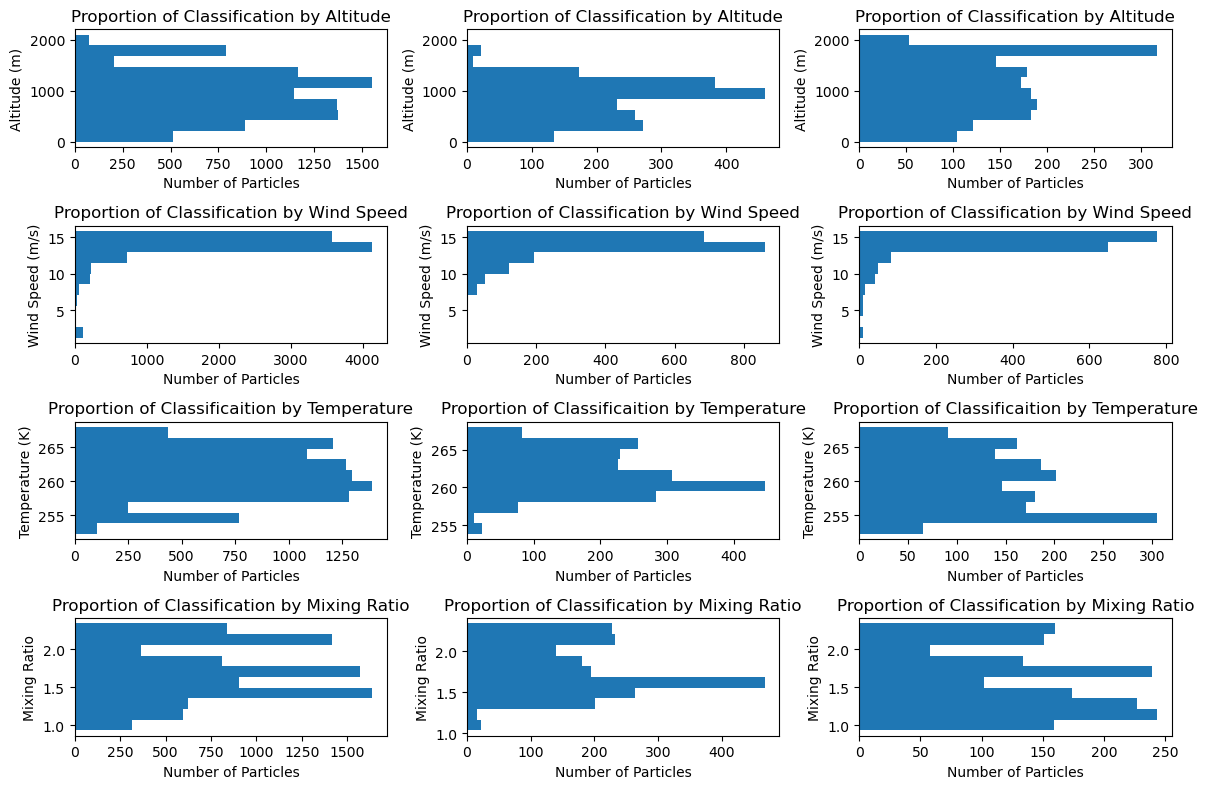

In [ ]:
# lets do some more statistics and stuff
# plot altitude vs the classification given, see if there's a pattern as the sonde floated higher
# repeat for temp/RH as well

# filter out all but the desired classification for each dataframe
# dataframes for plotting classification v altitude
df_plot0 = final_df[final_df['classifications'] == 0]
df_plot1 = final_df[final_df['classifications'] == 1]
df_plot2 = final_df[final_df['classifications'] == 2]

# set label colors
#colors = ['aggregate snow', 'broken snow', 'ice']

# variable-specific datasets
alt_data0 = df_plot0['Filtered Altitude (m) ']
alt_data1 = df_plot1['Filtered Altitude (m) ']
alt_data2 = df_plot2['Filtered Altitude (m) ']

temp_data0 = df_plot0['Filtered Temperature (K) ']
temp_data1 = df_plot1['Filtered Temperature (K) ']
temp_data2 = df_plot2['Filtered Temperature (K) ']

wspd_data0 = df_plot0['Filtered Wind Spd (m/s) ']
wspd_data1 = df_plot1['Filtered Wind Spd (m/s) ']
wspd_data2 = df_plot2['Filtered Wind Spd (m/s) ']

mr_data0 = df_plot0['Calculated Mixing Ratio ']
mr_data1 = df_plot1['Calculated Mixing Ratio ']
mr_data2 = df_plot2['Calculated Mixing Ratio ']

dew_data0 = df_plot0['Filtered Dewpoint (K) ']
dew_data1 = df_plot1['Filtered Dewpoint (K) ']
dew_data2 = df_plot2['Filtered Dewpoint (K) ']

fig, ax = plt.subplots(nrows = 4, ncols = 3, figsize=(12, 8))
for axes in ax.flat:
    axes.set_xlabel('Number of Particles')
    #axes.legend(loc = 'upper right')

ax[0,0].hist(alt_data0, bins = 10, range = (0, 2100), orientation = 'horizontal', stacked = True )
ax[0,0].set_ylabel('Altitude (m)')
ax[0,0].set_title("Proportion of Classification by Altitude")

ax[1,0].hist(wspd_data0, bins = 10, orientation = 'horizontal', stacked = True)
ax[1,0].set_ylabel('Wind Speed (m/s)')
ax[1,0].set_title('Proportion of Classification by Wind Speed')

ax[2,0].hist(temp_data0, bins = 10, orientation = 'horizontal', stacked = True)
ax[2,0].set_ylabel('Temperature (K)')
ax[2,0].set_title('Proportion of Classificaition by Temperature')

ax[3,0].hist(mr_data0, bins = 10, orientation = 'horizontal', stacked = True)
ax[3,0].set_ylabel('Mixing Ratio')
ax[3,0].set_title('Proportion of Classification by Mixing Ratio')

ax[0,1].hist(alt_data1, bins = 10, range = (0, 2100), orientation = 'horizontal', stacked = True)
ax[0,1].set_ylabel('Altitude (m)')
ax[0,1].set_title("Proportion of Classification by Altitude")

ax[1,1].hist(wspd_data1, bins = 10, orientation = 'horizontal', stacked = True)
ax[1,1].set_ylabel('Wind Speed (m/s)')
ax[1,1].set_title('Proportion of Classification by Wind Speed')

ax[2,1].hist(temp_data1, bins = 10, orientation = 'horizontal', stacked = True)
ax[2,1].set_ylabel('Temperature (K)')
ax[2,1].set_title('Proportion of Classificaition by Temperature')

ax[3,1].hist(mr_data1, bins = 10, orientation = 'horizontal', stacked = True)
ax[3,1].set_ylabel('Mixing Ratio')
ax[3,1].set_title('Proportion of Classification by Mixing Ratio')

ax[0,2].hist(alt_data2, bins = 10, range = (0, 2100), orientation = 'horizontal', stacked = True)
ax[0,2].set_ylabel('Altitude (m)')
ax[0,2].set_title("Proportion of Classification by Altitude")

ax[1,2].hist(wspd_data2, bins = 10, orientation = 'horizontal', stacked = True)
ax[1,2].set_ylabel('Wind Speed (m/s)')
ax[1,2].set_title('Proportion of Classification by Wind Speed')

ax[2,2].hist(temp_data2, bins = 10, orientation = 'horizontal', stacked = True)
ax[2,2].set_ylabel('Temperature (K)')
ax[2,2].set_title('Proportion of Classificaition by Temperature')

ax[3,2].hist(mr_data2, bins = 10, orientation = 'horizontal', stacked = True)
ax[3,2].set_ylabel('Mixing Ratio')
ax[3,2].set_title('Proportion of Classification by Mixing Ratio')

fig.tight_layout()


In [30]:
#ok, let's machine learn
#first, we split the data into two categories: the inputs and the target variable
X = final_df[['BrightHist1', 'BrightHist2', 'BrightHist3', 'BrightHist4', 'BrightHist5', 'BrightHist6', 'BrightHist7', 'BrightHist8', 'BrightHist9', 'BrightHist10', 
        'Bright_avg', 'Bright_count', 'Bright_max', 'Bright_median', 'e', 'irreg', 'maj', 'maxIrreg', 'min', 'minIrreg', 'r', 'Filtered Temperature (K) ',
        'Filtered Dewpoint (K) ', 'Filtered Pressure (mb) ']]
# TODO keep looking into using temp and dewpoint... the pool of cases is pretty small after all these datasets were merged... more may be needed
# TODO i removed 'prt' because if that's just the image particle number it should be pointless right?
y = final_df['classifications']

#in testing, I found that BrightHist2, 3, and 4 have "*****" string entries at some point, so we have to convert those to nan and drop them
#then, we make sure to rematch the y df to x so that they are the same length and play nice
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
y = y[X.index]

# print(X.shape)
# print(y.shape)

# Check for non-numeric entries in X --> this is where I found that some columns had strings hidden in there a few times
# def check_non_numeric(df):
#     for column in df.columns:
#         if not pd.to_numeric(df[column], errors='coerce').notna().all():
#             print(f"Non-numeric values found in column: {column}")

# check_non_numeric(X)

#now, we split the data into the training set and the testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# normalize the datasets to improve the algorithms
# possible scalers/transformers: StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer, QuantileTransformer, *PowerTransformer*
#PowerTransformer seems to give the highest overall accuracies, but Normalizer gives the absolute highest to RandomForest while hurting the others
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
###### Random Forest Model #######
# Create a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=140, random_state=42, bootstrap = True) #does bootstrap use replacement or no?

# Train the model on the training data
rf_classifier.fit(X_train_scaled, y_train)

# Make predictions on the testing data
rf_y_pred = rf_classifier.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, rf_y_pred)
print("Accuracy:", accuracy)

print("Classification Report: \n", classification_report(y_test, rf_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, rf_y_pred))

Accuracy: 0.8334651898734177
Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.94      0.90      1839
           1       0.82      0.52      0.63       394
           2       0.66      0.62      0.64       295

    accuracy                           0.83      2528
   macro avg       0.78      0.69      0.72      2528
weighted avg       0.83      0.83      0.83      2528

Confusion Matrix: 
 [[1721   43   75]
 [ 171  204   19]
 [ 110    3  182]]


In [32]:
###### Logistic Regression Model ######
#make the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

#make some predictions
LR_y_pred = model.predict(X_test_scaled)

#evaluate the model and print out some metrics/the results
accuracy = accuracy_score(y_test, LR_y_pred)
print("Accuracy = ", accuracy)

print("Classification Report: \n", classification_report(y_test, LR_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, LR_y_pred))

Accuracy =  0.803006329113924
Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.98      0.88      1839
           1       0.85      0.42      0.56       394
           2       0.76      0.24      0.36       295

    accuracy                           0.80      2528
   macro avg       0.80      0.54      0.60      2528
weighted avg       0.80      0.80      0.77      2528

Confusion Matrix: 
 [[1794   27   18]
 [ 224  166    4]
 [ 222    3   70]]


In [33]:
###### Support Vector Machines ######
#create a SVM classifier
classifier = svm.SVC(kernel='rbf', gamma=0.1, random_state=42) # rbf very slightly beats out poly, but but are essentially tied for the best
#0.7329700272479565
#train the model using the training sets
classifier.fit(X_train_scaled, y_train)
#Predict the response for test dataset
SVM_y_pred = classifier.predict(X_test_scaled)

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",accuracy_score(y_test, SVM_y_pred))
# Model Precision: what percentage of positive tuples are labeled as such?
#print("Precision:",precision_score(y_test, SVM_y_pred, average = 'micro'))
# Model Recall: what percentage of positive tuples are labelled as such?
#print("Recall:",recall_score(y_test, SVM_y_pred, average = 'micro'))
print("Classification Report: \n", classification_report(y_test, SVM_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, SVM_y_pred))

Accuracy: 0.7666139240506329
Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.99      0.86      1839
           1       0.89      0.28      0.43       394
           2       0.00      0.00      0.00       295

    accuracy                           0.77      2528
   macro avg       0.55      0.43      0.43      2528
weighted avg       0.69      0.77      0.69      2528

Confusion Matrix: 
 [[1826   13    0]
 [ 282  112    0]
 [ 294    1    0]]


In [34]:
###### K Nearest Neighbors Model ######
knn_model = KNeighborsClassifier(n_neighbors = 32, weights = 'distance') # n_neighbors = 32 is the highest I found || random state doesn't work here
knn_model.fit(X_train_scaled, y_train)
#make predictions on the test data
knn_y_pred = knn_model.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, knn_y_pred)
print("Accuracy:", accuracy)
print("Classification Report: \n", classification_report(y_test, knn_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, knn_y_pred))

Accuracy: 0.776503164556962
Classification Report: 
               precision    recall  f1-score   support

           0       0.78      0.97      0.86      1839
           1       0.88      0.37      0.52       394
           2       0.47      0.09      0.15       295

    accuracy                           0.78      2528
   macro avg       0.71      0.48      0.51      2528
weighted avg       0.76      0.78      0.73      2528

Confusion Matrix: 
 [[1789   19   31]
 [ 247  147    0]
 [ 267    1   27]]


In [35]:
###### Gaussian Naive Bayes ######
#we have to encode the classes to numeric so that the model runs
#this one works best with the Normalizer scaler

gnb = GaussianNB() #random state doesn't work here

# Train the classifier on the training data
gnb.fit(X_train_scaled, y_train)

# Make predictions on the testing data
gnb_y_pred = gnb.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, gnb_y_pred)
print("Accuracy: ", accuracy)

print("Classification Report: \n", classification_report(y_test, gnb_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, gnb_y_pred))

Accuracy:  0.5233386075949367
Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.50      0.63      1839
           1       0.65      0.36      0.46       394
           2       0.22      0.92      0.35       295

    accuracy                           0.52      2528
   macro avg       0.57      0.59      0.48      2528
weighted avg       0.75      0.52      0.57      2528

Confusion Matrix: 
 [[912  75 852]
 [132 140 122]
 [ 22   2 271]]


In [36]:
# automated random forest tuner - lowkey made it slightly worse
# param_grid = { "n_estimators"      : [250, 300],
#            "criterion"         : ["gini", "entropy"],
#            "max_features"      : [3, 5],
#            "max_depth"         : [10, 20],
#            "min_samples_split" : [2, 4] ,
#            "bootstrap": [True, False]}
# random_search = RandomizedSearchCV(RandomForestClassifier(), param_grid)
# random_search.fit(X_train, y_train)
# print(random_search.best_estimator_)